## Resampling cuture data at varipous concentration
 - Understand FPS affect on concentration estimate 
 - Sample From simulated distributions 
 - Sample from corrected IFCB distributions
 

In [1]:
## Simulate poisson process with uniform arrival times

import numpy as np

def simulate_uniform_particles(
    mean_particles, ## Mean number of particles in the whole 5ml syringe
    run_duration=1200, ## Time in seconds 
    seed=None
):
    rng = np.random.default_rng(seed)

    n_particles = rng.poisson(mean_particles)

    arrival_times = np.sort(
        rng.uniform(0, run_duration, n_particles)
    )

    return arrival_times

In [2]:
import numpy as np
import pandas as pd

def simulate_ifcb_sampling(arrival_times, inhibit_time=0.08):
    """
    Simulate IFCB sampling with a fixed inhibit time after each accepted trigger.

    Parameters
    ----------
    arrival_times : array-like
        Sorted or unsorted underlying particle arrival times in seconds.
    inhibit_time : float
        Time after each accepted trigger during which new particles cannot be sampled.

    Returns
    -------
    sampled_df : pandas.DataFrame
        DataFrame containing accepted particle arrival times.
    rejected_df : pandas.DataFrame
        DataFrame containing rejected particle arrival times.
    """

    arrival_times = np.sort(np.asarray(arrival_times))

    sampled_flags = []
    next_available_time = 0

    for t in arrival_times:
        if t >= next_available_time:
            sampled_flags.append(True)
            next_available_time = t + inhibit_time
        else:
            sampled_flags.append(False)

    df = pd.DataFrame({
        "arrival_time": arrival_times,
        "sampled": sampled_flags
          })

    return df

### For uniform distribution

In [7]:
import pandas as pd

#particles = [1000, 5000, 10000, 25000, 50000, 75000, 100000, 125000, 150000, 175000, 200000, 250000, 300000, 350000, 400000, 450000, 500000]

particles = np.arange(500, 75001, 500) 

summary_rows = []

for p in particles:

    times = simulate_uniform_particles(mean_particles=p)

    ifcb_df = simulate_ifcb_sampling(
        times,
        inhibit_time=0.08
    )

    underlying_particles = len(ifcb_df)
    sampled_particles = int(ifcb_df["sampled"].sum())
    rejected_particles = int((~ifcb_df["sampled"]).sum())

    Volume_analyzed = (1200 - sampled_particles * 0.08) / 240
    FPS = sampled_particles / 1200
    conc_estimate = sampled_particles / Volume_analyzed

    summary_rows.append({
        "target_particles": p,
        "underlying_particles": underlying_particles,
        "sampled_particles": sampled_particles,
        "rejected_particles": rejected_particles,
        "Volume_analyzed": Volume_analyzed,
        "FPS": FPS,
        "Target_concentration": p / 5, ## Assuming 5ml syringe
        "Concentration_estimate": conc_estimate
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df)

     target_particles  underlying_particles  sampled_particles  \
0                 500                   483                467   
1                1000                  1023                953   
2                1500                  1481               1342   
3                2000                  2020               1772   
4                2500                  2466               2139   
..                ...                   ...                ...   
145             73000                 73189              12476   
146             73500                 73730              12445   
147             74000                 74313              12513   
148             74500                 74269              12469   
149             75000                 74811              12474   

     rejected_particles  Volume_analyzed        FPS  Target_concentration  \
0                    16         4.844333   0.389167                 100.0   
1                    70         4.682333   0.794167  

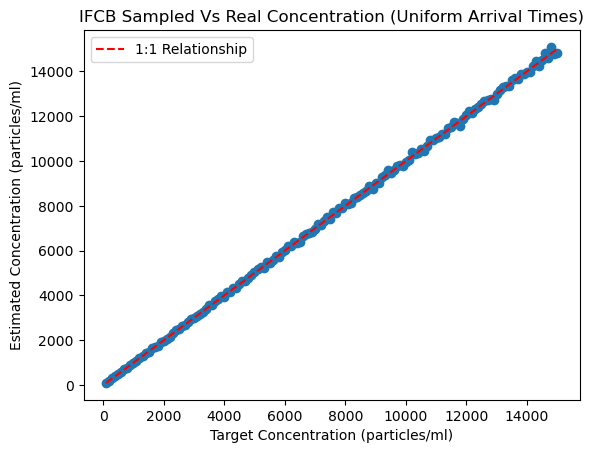

In [11]:
import matplotlib.pyplot as plt

plt.scatter(summary_df["Target_concentration"], summary_df["Concentration_estimate"])
plt.plot(summary_df["Target_concentration"], summary_df["Target_concentration"], color='red', linestyle='--', label="1:1 Relationship")
plt.xlabel("Target Concentration (particles/ml)")
plt.ylabel("Estimated Concentration (particles/ml)")
plt.title("IFCB Sampled Vs Real Concentration (Uniform Arrival Times)")
plt.legend()
plt.show()

## Can also generate non uniform distributions using the beta distribution

see this link for examples of the beta distribution : ![alt text](https://towardsdatascience.com/wp-content/uploads/2023/10/1-R7czN-vorNob8l74xJMmg.png)

In [12]:
import numpy as np
import pandas as pd

def simulate_skewed_particles(
    mean_particles,
    run_duration=1200,
    beta_a=1,
    beta_b=3,
    seed=None
):
    rng = np.random.default_rng(seed)

    n_particles = rng.poisson(mean_particles)

    runtime_fraction = rng.beta(
        beta_a,
        beta_b,
        size=n_particles
    )

    arrival_times = np.sort(runtime_fraction * run_duration)

    return pd.DataFrame({
        "arrival_time": arrival_times,
        "runtime_fraction": arrival_times / run_duration
    })

     target_particles  underlying_particles  sampled_particles  \
0                 500                   501                475   
1                1000                  1001                919   
2                1500                  1501               1336   
3                2000                  2001               1733   
4                2500                  2502               2093   
..                ...                   ...                ...   
145             73000                 73009              11838   
146             73500                 73509              11851   
147             74000                 74009              11869   
148             74500                 74509              11881   
149             75000                 75009              11892   

     rejected_particles  Volume_analyzed       FPS  Target_concentration  \
0                    26         4.841667  0.395833                 100.0   
1                    82         4.693667  0.765833     

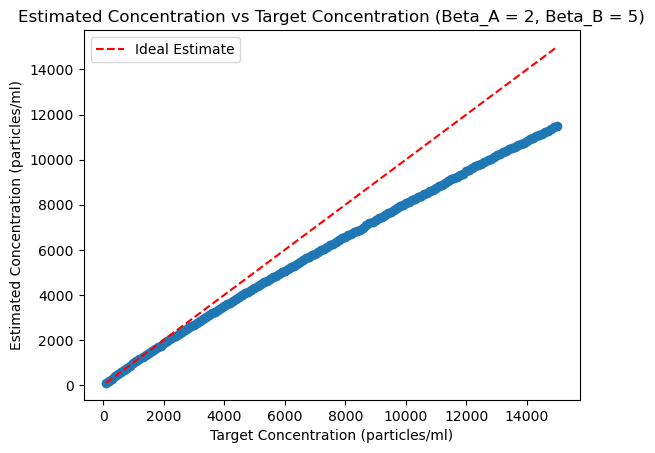

In [ ]:
## For a single beta distribution

import pandas as pd

#particles = [1000, 5000, 10000, 25000, 50000, 75000, 100000]

summary_rows = []

for p in particles:

    times = simulate_skewed_particles(mean_particles=p,
                                       beta_a=1.134,
                                       beta_b=1.774,
                                       run_duration=1200,
                                       seed=1)

    
    ifcb_df = simulate_ifcb_sampling(
        times["arrival_time"],
        inhibit_time=0.08
    )

    underlying_particles = len(ifcb_df)
    sampled_particles = int(ifcb_df["sampled"].sum())
    rejected_particles = int((~ifcb_df["sampled"]).sum())

    Volume_analyzed = (1200 - sampled_particles * 0.08) / 240
    FPS = sampled_particles / 1200
    conc_estimate = sampled_particles / Volume_analyzed

    summary_rows.append({
        "target_particles": p,
        "underlying_particles": underlying_particles,
        "sampled_particles": sampled_particles,
        "rejected_particles": rejected_particles,
        "Volume_analyzed": Volume_analyzed,
        "FPS": FPS,
        "Target_concentration": p / 5, ## Assuming 5ml syringe
        "Concentration_estimate": conc_estimate
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df)
plt.scatter(summary_df["Target_concentration"], summary_df["Concentration_estimate"])
plt.plot(summary_df["Target_concentration"], summary_df["Target_concentration"], color='red', linestyle='--', label="Ideal Estimate")
plt.xlabel("Target Concentration (particles/ml)")
plt.ylabel("Estimated Concentration (particles/ml)")
plt.title("Estimated Concentration vs Target Concentration (Beta_A = 2, Beta_B = 5)")
plt.legend()
plt.show()

In [ ]:
## For mutliple beta distributions plot an example distribution and the resulting concentration estimates
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

particles = np.arange(500, 25001, 500)

# Replace these with the beta distributions you want to compare
beta_sets = [
    (1, 1),
    (1.25, 2.0),
    (1.5, 3.0),
    (1.5, 10.0),
]


def run_simulation(beta_a, beta_b):
    summary_rows = []

    for p in particles:
        times = simulate_skewed_particles(
            mean_particles=p,
            beta_a=beta_a,
            beta_b=beta_b,
            run_duration=1200,
            seed=1
        )

        ifcb_df = simulate_ifcb_sampling(
            times["arrival_time"],
            inhibit_time=0.08
        )

        sampled_particles = int(ifcb_df["sampled"].sum())
        rejected_particles = int((~ifcb_df["sampled"]).sum())

        volume_analyzed = (
            1200 - sampled_particles * 0.08
        ) / 240

        concentration_estimate = (
            sampled_particles / volume_analyzed
        )

        summary_rows.append({
            "target_particles": p,
            "sampled_particles": sampled_particles,
            "rejected_particles": rejected_particles,
            "volume_analyzed": volume_analyzed,
            "target_concentration": p / 5,
            "concentration_estimate": concentration_estimate
        })

    return pd.DataFrame(summary_rows)


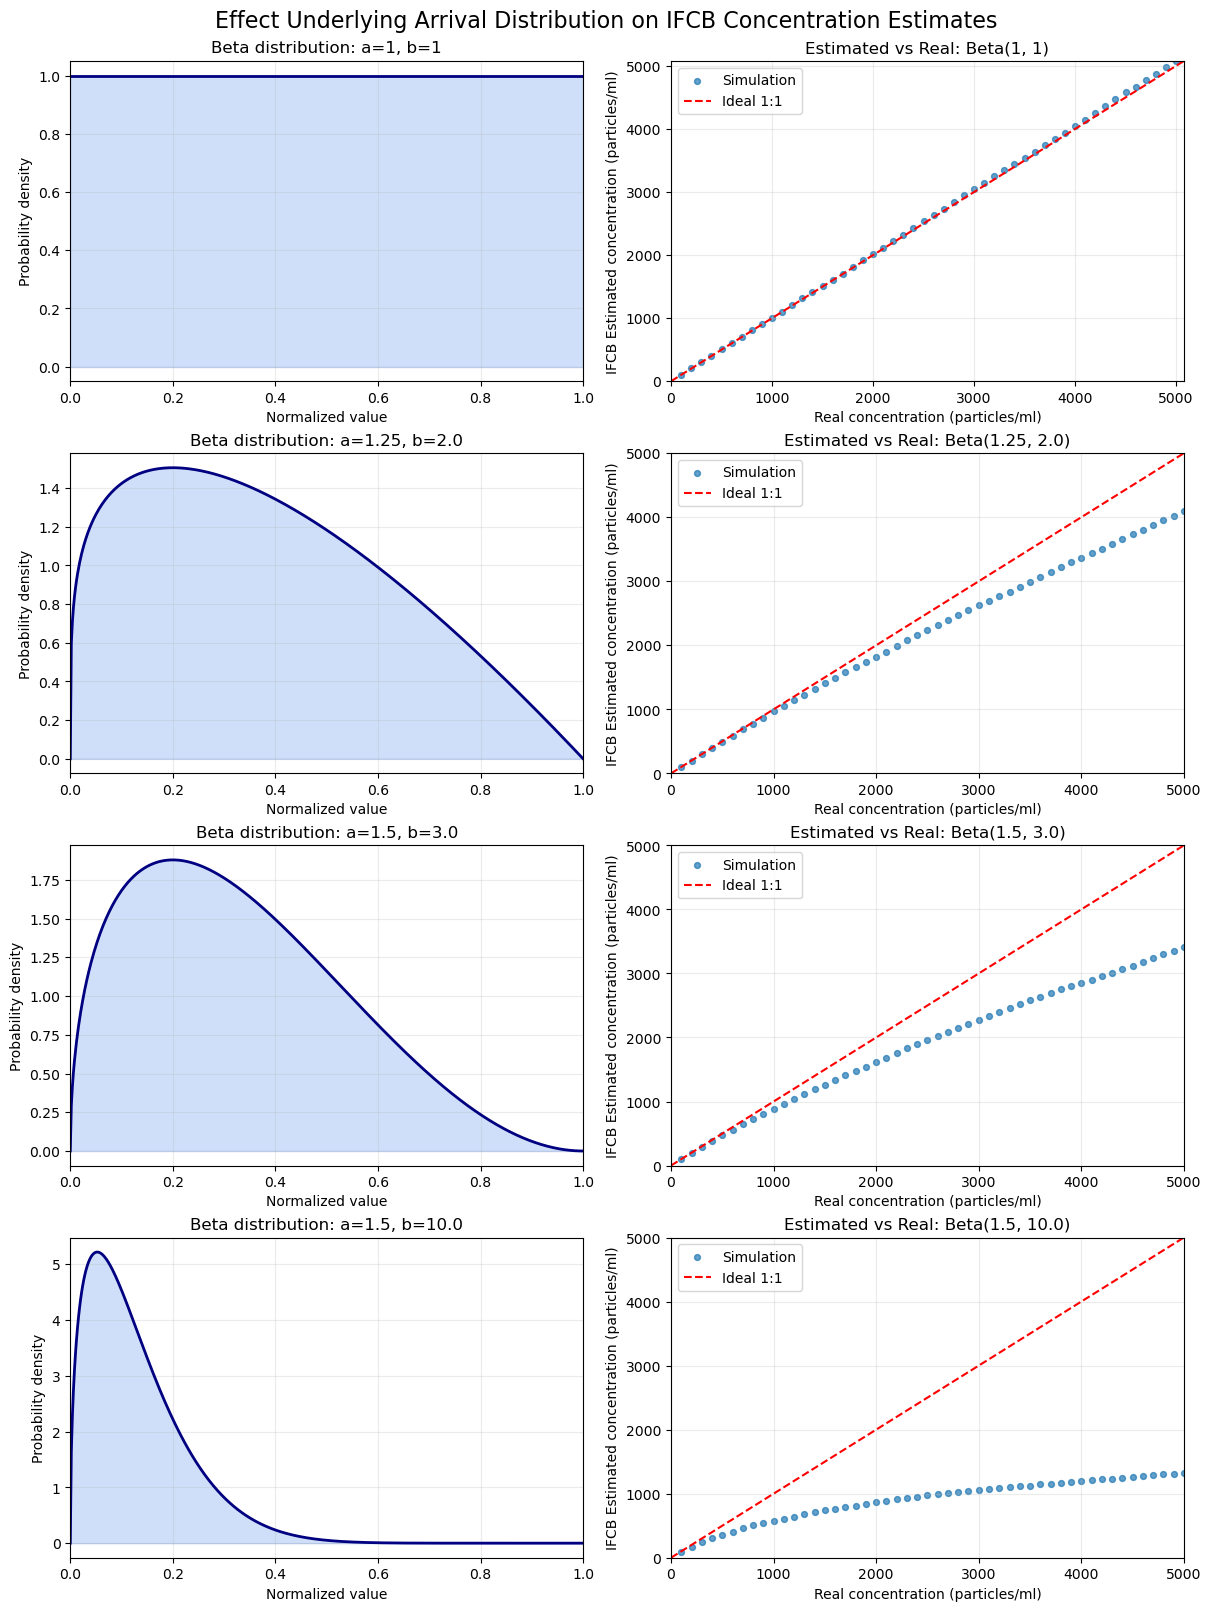

In [38]:
fig, axes = plt.subplots(
    nrows=len(beta_sets),
    ncols=2,
    figsize=(12, 16),
    constrained_layout=True
)

x_beta = np.linspace(0, 1, 500)

for row, (beta_a, beta_b) in enumerate(beta_sets):
    ax_distribution = axes[row, 0]
    ax_concentration = axes[row, 1]

    # Beta distribution
    pdf = beta_dist.pdf(x_beta, beta_a, beta_b)

    ax_distribution.plot(
        x_beta,
        pdf,
        color="navy",
        linewidth=2
    )

    ax_distribution.fill_between(
        x_beta,
        pdf,
        color="cornflowerblue",
        alpha=0.3
    )

    ax_distribution.set_title(
        f"Beta distribution: a={beta_a}, b={beta_b}"
    )
    ax_distribution.set_xlabel("Normalized value")
    ax_distribution.set_ylabel("Probability density")
    ax_distribution.set_xlim(0, 1)
    ax_distribution.grid(alpha=0.25)

    # Run simulation
    summary_df = run_simulation(beta_a, beta_b)

    x = summary_df["target_concentration"]
    y = summary_df["concentration_estimate"]

    # Concentration comparison
    ax_concentration.scatter(
        x,
        y,
        s=18,
        alpha=0.7,
        label="Simulation"
    )

    max_value = max(x.max(), y.max())

    ax_concentration.plot(
        [0, max_value],
        [0, max_value],
        color="red",
        linestyle="--",
        label="Ideal 1:1"
    )

    ax_concentration.set_title(
        f"Estimated vs Real: Beta({beta_a}, {beta_b})"
    )
    ax_concentration.set_xlabel(
        "Real concentration (particles/ml)"
    )
    ax_concentration.set_ylabel(
        "IFCB Estimated concentration (particles/ml)"
    )
    ax_concentration.set_xlim(0, max_value)
    ax_concentration.set_ylim(0, max_value)
    ax_concentration.grid(alpha=0.25)
    ax_concentration.legend()

fig.suptitle(
    "Effect Underlying Arrival Distribution on IFCB Concentration Estimates",
    fontsize=16
)

plt.show()

### Resampling from Culture distributions 
##### Using the IPW corrected distributions

In [ ]:
## Load existing corrected arrival data
Alex_corrected = pd.read_json("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/Alex/AlexHighV_corrected_arrivals.json")
Jata_corrected = pd.read_json("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/jataHighV/jataHighV_corrected_arrivals.json")

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Particle loads to test
particles = np.arange(500, 25001, 500)

# Existing empirical arrival-time distributions
arrival_distributions = {
    "Alex corrected": Alex_corrected["arrival_times"],
    "Jata corrected": Jata_corrected["arrival_times"],
}


def subsample_particles(arrival_times, p, rng):
    """Randomly select p existing particles without replacement."""
    arrival_times = np.asarray(arrival_times, dtype=float)
    arrival_times = arrival_times[np.isfinite(arrival_times)]

    if p > len(arrival_times):
        raise ValueError(
            f"Cannot sample {p} particles from only "
            f"{len(arrival_times)} available particles."
        )

    selected_times = rng.choice(
        arrival_times,
        size=p,
        replace=False
    )

    # IFCB sampling expects chronological arrival times
    return pd.DataFrame({
        "arrival_time": np.sort(selected_times)
    })


def run_simulation(arrival_times, seed=1):
    """Subsample particles and pass them through the simulated IFCB."""
    rng = np.random.default_rng(seed)
    summary_rows = []

    for p in particles:
        times = subsample_particles(
            arrival_times=arrival_times,
            p=p,
            rng=rng
        )

        ifcb_df = simulate_ifcb_sampling(
            times["arrival_time"],
            inhibit_time=0.08
        )

        underlying_particles = len(ifcb_df)
        sampled_particles = int(ifcb_df["sampled"].sum())
        rejected_particles = int((~ifcb_df["sampled"]).sum())

        volume_analyzed = (
            1200 - sampled_particles * 0.08
        ) / 240

        concentration_estimate = (
            sampled_particles / volume_analyzed
        )

        summary_rows.append({
            "target_particles": p,
            "underlying_particles": underlying_particles,
            "sampled_particles": sampled_particles,
            "rejected_particles": rejected_particles,
            "volume_analyzed": volume_analyzed,
            "target_concentration": p / 5,
            "concentration_estimate": concentration_estimate
        })

    return pd.DataFrame(summary_rows)



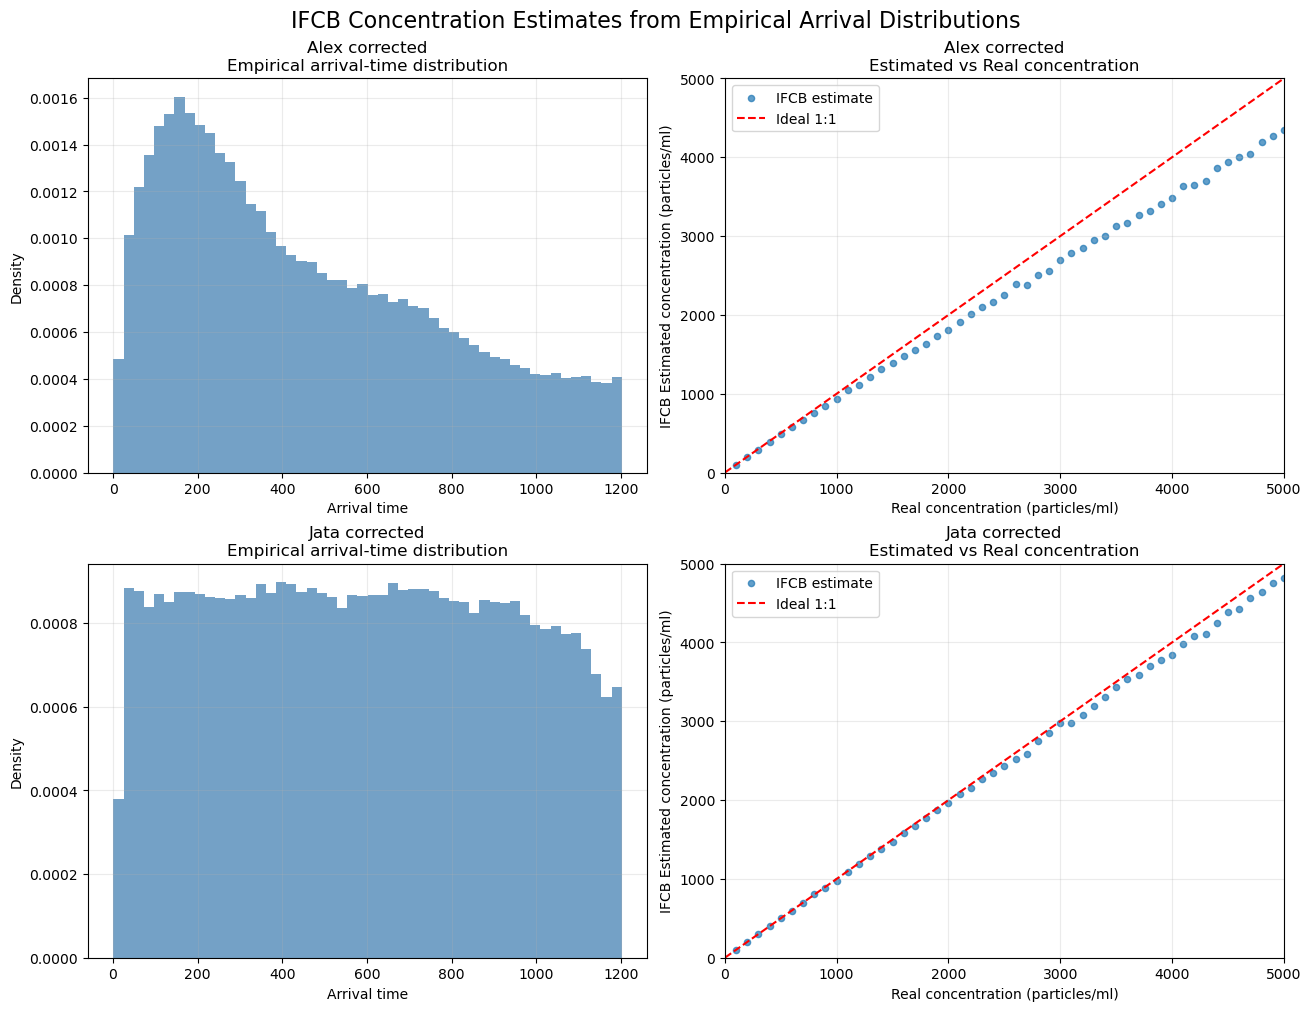

In [51]:

# Run both empirical distributions
summary_results = {
    name: run_simulation(arrival_times, seed=1)
    for name, arrival_times in arrival_distributions.items()
}


# Create one row per distribution:
# column 1 = empirical arrival-time distribution
# column 2 = estimated vs target concentration
fig, axes = plt.subplots(
    nrows=len(arrival_distributions),
    ncols=2,
    figsize=(13, 10),
    constrained_layout=True
)

for row, (name, arrival_times) in enumerate(
    arrival_distributions.items()
):
    ax_distribution = axes[row, 0]
    ax_concentration = axes[row, 1]

    arrival_times = np.asarray(arrival_times, dtype=float)
    arrival_times = arrival_times[np.isfinite(arrival_times)]

    # Plot empirical arrival-time distribution
    ax_distribution.hist(
        arrival_times,
        bins=50,
        density=True,
        color="steelblue",
        alpha=0.75
    )

    ax_distribution.set_title(
        f"{name}\nEmpirical arrival-time distribution"
    )
    ax_distribution.set_xlabel("Arrival time")
    ax_distribution.set_ylabel("Density")
    ax_distribution.grid(alpha=0.25)

    # Plot estimated versus target concentration
    summary_df = summary_results[name]

    x = summary_df["target_concentration"]
    y = summary_df["concentration_estimate"]

    ax_concentration.scatter(
        x,
        y,
        s=20,
        alpha=0.7,
        label="IFCB estimate"
    )

    max_value = max(x.max(), y.max())

    ax_concentration.plot(
        [0, max_value],
        [0, max_value],
        color="red",
        linestyle="--",
        label="Ideal 1:1"
    )

    ax_concentration.set_title(
        f"{name}\nEstimated vs Real concentration"
    )
    ax_concentration.set_xlabel(
        "Real concentration (particles/ml)"
    )
    ax_concentration.set_ylabel(
        "IFCB Estimated concentration (particles/ml)"
    )
    ax_concentration.set_xlim(0, max_value)
    ax_concentration.set_ylim(0, max_value)
    ax_concentration.grid(alpha=0.25)
    ax_concentration.legend()

fig.suptitle(
    "IFCB Concentration Estimates from Empirical Arrival Distributions",
    fontsize=16
)

plt.show()